In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf
import numpy as np

from spline_distribution.tensorflow.distribution import SimpleDensityEstimator

## Train PDF

In [3]:
estimator = SimpleDensityEstimator(3, dtype=tf.float64)

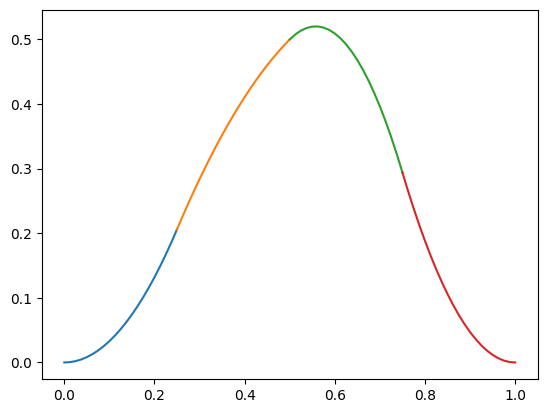

In [4]:
estimator.get_spline().plot()

In [5]:
estimator.expected_value()

0.5219902867641104

In [6]:
import tensorflow as tf
import numpy as np

In [7]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000))
ts

<tf.Tensor: shape=(100000,), dtype=float64, numpy=
array([0.42505399, 0.4792767 , 0.53493896, ..., 0.54748449, 0.52715335,
       0.61962305])>

In [8]:
estimator.knots

<tf.Tensor: shape=(11,), dtype=float64, numpy=array([0.  , 0.  , 0.  , 0.  , 0.25, 0.5 , 0.75, 1.  , 1.  , 1.  , 1.  ])>

In [9]:
estimator.logits

<tf.Variable 'Variable:0' shape=(2,) dtype=float64, numpy=array([0.24849835, 0.60404157])>

In [10]:
estimator.train(ts, n_epochs=20, batch_size=4096)

Epoch 1/20 17.16156028084485
Epoch 2/20 17.153308714348537
Epoch 3/20 17.146693200363597
Epoch 4/20 17.141559809963795
Epoch 5/20 17.137695202345366
Epoch 6/20 17.13486984945546
Epoch 7/20 17.132864647371076
Epoch 8/20 17.13148347520816
Epoch 9/20 17.13056008434458
Epoch 10/20 17.129960589615724
Epoch 11/20 17.129582308760035
Epoch 12/20 17.129350054043826
Epoch 13/20 17.129211116846157
Epoch 14/20 17.129130019002364
Epoch 15/20 17.12908376341849
Epoch 16/20 17.129057952302972
Epoch 17/20 17.129043854273494
Epoch 18/20 17.12903632573582
Epoch 19/20 17.129032414888258
Epoch 20/20 17.12903046655084


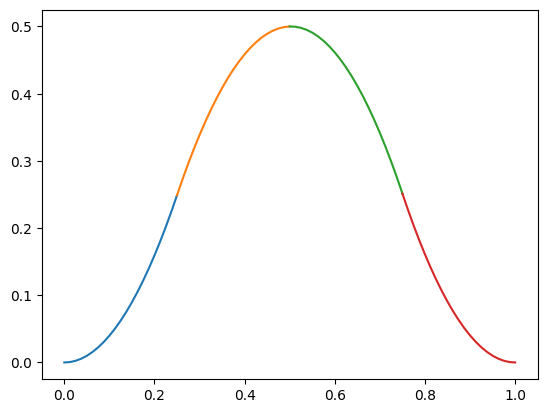

In [11]:
estimator.get_spline().plot()

In [12]:
estimator.expected_value()

0.500604994930219

## Train CDF

In [13]:
estimator = SimpleDensityEstimator(7, dtype=tf.float64)

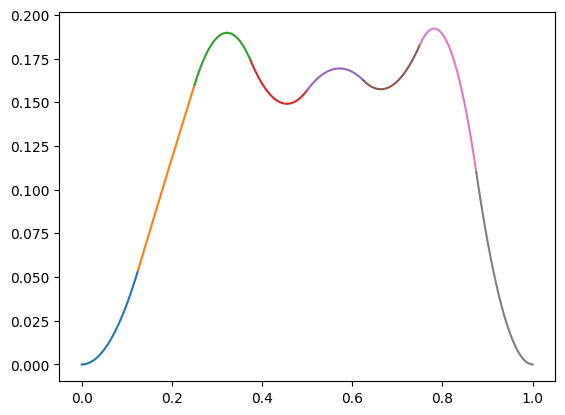

In [14]:
estimator.get_spline().plot()

In [15]:
estimator.expected_value()

0.5253377611522051

In [16]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000), dtype=tf.float64)
t_preds = tf.convert_to_tensor(np.random.uniform(size=100_000), dtype=tf.float64)
over_pred_vec = tf.where(t_preds > ts, 1.0, 0.0)

In [17]:
estimator.train_cdf(t_preds, over_pred_vec, n_epochs=20, batch_size=1024)

Epoch 1/20 23.124100372076377
Epoch 2/20 22.197843682847928
Epoch 3/20 21.29846511491689
Epoch 4/20 20.39390141922589
Epoch 5/20 19.485356099407866
Epoch 6/20 18.59480521007829
Epoch 7/20 17.74764623122906
Epoch 8/20 16.96363248570553
Epoch 9/20 16.25403088436541
Epoch 10/20 15.62227144887879
Epoch 11/20 15.066065091413522
Epoch 12/20 14.579687221286283
Epoch 13/20 14.155809106112192
Epoch 14/20 13.786730826939554
Epoch 15/20 13.465099561725138
Epoch 16/20 13.18426243442159
Epoch 17/20 12.938390431972847
Epoch 18/20 12.722473567044505
Epoch 19/20 12.532252378159733
Epoch 20/20 12.364124543135045


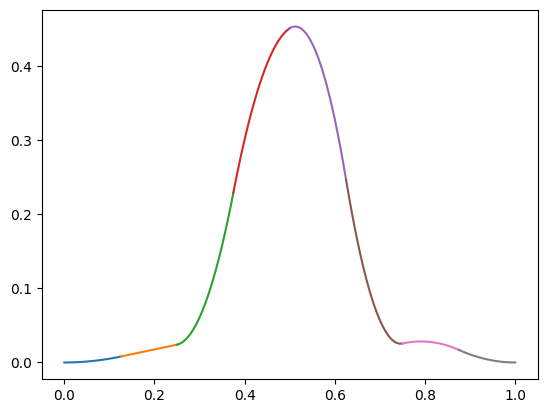

In [18]:
estimator.get_spline().plot()

In [19]:
estimator.expected_value()

0.5059349829820936

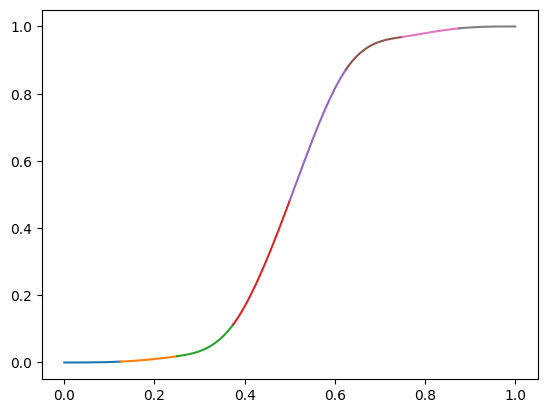

In [20]:
estimator.get_cdf_spline().plot()

## Auction scenario?

In [21]:
n_bidders = 5
n_items = 100_000
values = np.random.uniform(size=n_items)
get_smart_p = np.random.uniform(size=(n_items, n_bidders))
perceptions = np.sqrt(np.random.uniform(size=(n_items, n_bidders)) * values.reshape((-1, 1)))
perceptions = np.where(get_smart_p > 0.9, perceptions, perceptions / 3)

In [22]:
normal_bids = perceptions.max(axis=1)

In [23]:
normal_bids.shape

(100000,)

In [24]:
(get_smart_p.max(axis=1) > 0.9).sum()

41183

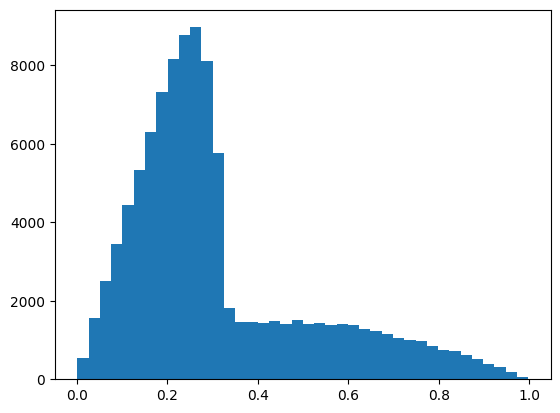

In [25]:
import matplotlib.pyplot as plt
plt.hist(normal_bids, bins=40)
plt.show()

In [26]:
bid_estimator = SimpleDensityEstimator(12)

In [27]:
bid_estimator.train(tf.convert_to_tensor(normal_bids, dtype=tf.float64), n_epochs=30, batch_size=1024)

Epoch 1/30 237.37258708540233
Epoch 2/30 231.30096694660224
Epoch 3/30 226.26246077227333
Epoch 4/30 222.11877337882228
Epoch 5/30 218.74152689318439
Epoch 6/30 216.02125042549
Epoch 7/30 213.8555456893478
Epoch 8/30 212.1466523748953
Epoch 9/30 210.80527114333205
Epoch 10/30 209.7541285401855
Epoch 11/30 208.92937911337353
Epoch 12/30 208.28009420303258
Epoch 13/30 207.76660282992378
Epoch 14/30 207.35840311058368
Epoch 15/30 207.0321400437272
Epoch 16/30 206.769902400081
Epoch 17/30 206.55790289475428
Epoch 18/30 206.3854969948268
Epoch 19/30 206.24445689088023
Epoch 20/30 206.12842227993588
Epoch 21/30 206.03247246217825
Epoch 22/30 205.95278715119883
Epoch 23/30 205.8863785805559
Epoch 24/30 205.83088441358166
Epoch 25/30 205.7844124990589
Epoch 26/30 205.74542797489653
Epoch 27/30 205.71267284386747
Epoch 28/30 205.68510881048041
Epoch 29/30 205.66187578224512
Epoch 30/30 205.64226047908699


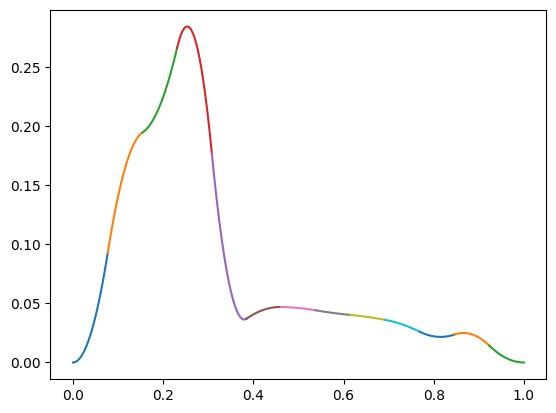

In [28]:
bid_estimator.get_spline().plot()

In [29]:
bid_estimator.expected_value()

0.3159506408993962

In [30]:
normal_bids.mean()

0.3120510131864623

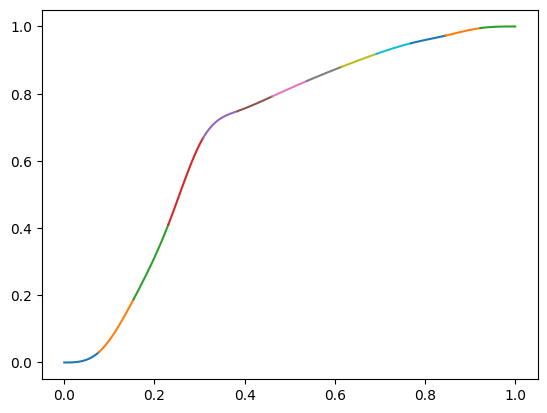

In [31]:
bid_estimator.get_cdf_spline().plot()

#### Look at it, it's beautiful

Now I want to train a distribution that looks at what happens if we interfere

In [32]:
floor_estimator = SimpleDensityEstimator(12)

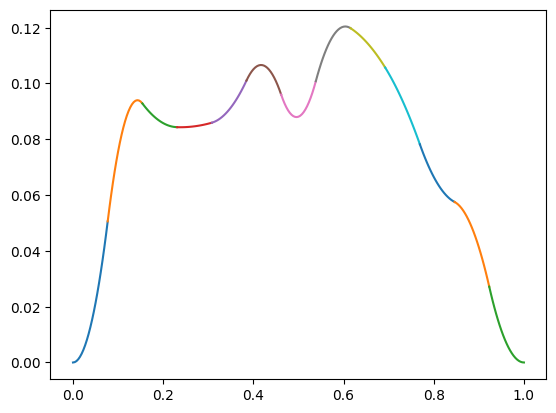

In [33]:
floor_estimator.get_spline().plot()

In [34]:
floors = np.random.uniform(0.01, 0.99, size=100_000)
new_bids = np.where(floors > normal_bids * 1.2, 0.0, np.maximum(floors, normal_bids))
over_pred_vec = (new_bids == 0).astype(int)

In [35]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024)

Epoch 1/20 45.34169558189065
Epoch 2/20 44.04063875755184
Epoch 3/20 43.05433377320561
Epoch 4/20 42.314964253742076
Epoch 5/20 41.76809775749991
Epoch 6/20 41.368765884469624
Epoch 7/20 41.07811306728395
Epoch 8/20 40.86439307717629
Epoch 9/20 40.703708058926715
Epoch 10/20 40.57932137062751
Epoch 11/20 40.48013381421074
Epoch 12/20 40.399033918560704
Epoch 13/20 40.331514131568504
Epoch 14/20 40.27466802175896
Epoch 15/20 40.226534200783505
Epoch 16/20 40.18569928079883
Epoch 17/20 40.15107162249122
Epoch 18/20 40.12175808093985
Epoch 19/20 40.096998972358016
Epoch 20/20 40.076134372608976


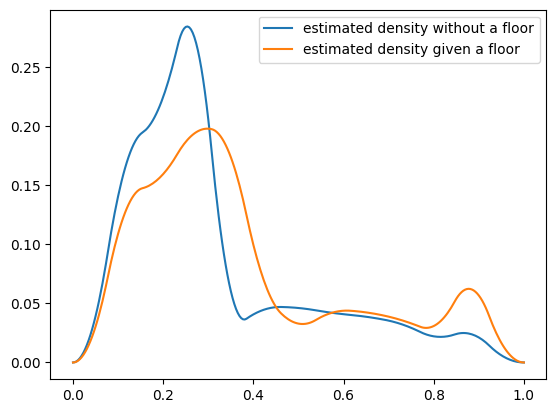

In [36]:
bid_estimator.get_spline().plot(segmented=False, label='estimated density without a floor')
floor_estimator.get_spline().plot(segmented=False, label='estimated density given a floor')
plt.legend()

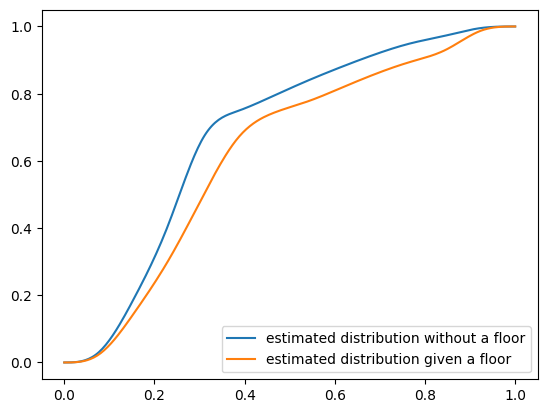

In [37]:
bid_estimator.get_cdf_spline().plot(segmented=False, label='estimated distribution without a floor')
floor_estimator.get_cdf_spline().plot(segmented=False, label='estimated distribution given a floor')
plt.legend()

In [38]:
bid_estimator.expected_value(), floor_estimator.expected_value()

(0.3159506408993962, 0.37359044775915645)

In [39]:
np.mean(normal_bids), np.mean(new_bids)

(0.3120510131864623, 0.1663634709818208)

In [40]:
def binary_search(y_func, target, lo=0, hi=1, max_iter=10, tol=1e-6, increasing=True):
    """Binary search for monotonic functions"""
    x = (lo + hi) / 2
    y = y_func(x)
    for _ in range(max_iter):
        if (y - tol) <= target <= (y + tol):
            return x

        if (y < target and increasing) or (y > target and not increasing):
            lo = x
        else:
            hi = x

        x = (lo + hi) / 2
        y = y_func(x)
    return x

def binary_maximizer(y_func, lo=0, hi=1, max_iter=10, tol=1e-8):
    """Binary search for monotonic functions"""
    assert lo < hi

    x = (lo + hi) / 2
    x_diff = x - lo
    y_lo = y_func(lo)
    y_hi = y_func(hi)

    for _ in range(max_iter):
        if x_diff < tol:
            return x
        if y_lo >= y_hi:
            hi = x
            y_hi = y_func(hi)
        else:
            lo = x
            y_lo = y_func(lo)
        x = (lo + hi) / 2
        x_diff = x - lo

    return x

In [44]:
bid_cdf = bid_estimator.get_cdf_spline()
floor_cdf = floor_estimator.get_cdf_spline()

In [45]:
optimal_floor = np.round(binary_search(
    lambda x: floor_estimator.expected_value(x) + bid_cdf.get_y(x) * (1 - floor_cdf.get_y(x)) * x,
    normal_bids.mean(),
    increasing=False), decimals=2)
optimal_floor

0.38

In [46]:
spline = floor_estimator.get_spline()
optimal_floor2 = np.round(binary_maximizer(spline.get_y), decimals=2)
optimal_floor2

0.3

In [47]:
# optimal_floor = 0.25
optimized_bids = np.where(optimal_floor > normal_bids * 1.2, 0.0, np.maximum(optimal_floor, normal_bids))
# over_pred_vec = (new_bids == 0).astype(int)

In [48]:
optimized_bids.mean()

0.1736298749305679

In [49]:
normal_bids.mean()

0.3120510131864623

In [50]:
floor_estimator.expected_value(optimal_floor)

0.21920452153280223

In [51]:
most_dense_t = np.argmax(floor_estimator.get_spline().get_y_batched(np.linspace(0, 1, 101))) / 100
most_dense_t

0.3

In [52]:
np.corrcoef(normal_bids, new_bids)

array([[1.        , 0.80530786],
       [0.80530786, 1.        ]])

In [53]:
optimal_floor2, most_dense_t

(0.3, 0.3)

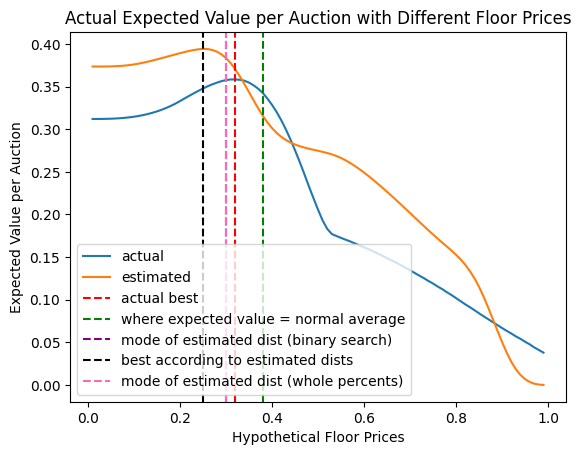

In [54]:
bid_cdf = bid_estimator.get_cdf_spline()
floor_cdf = floor_estimator.get_cdf_spline()

hyp_floors = np.arange(0.01, 1.0, 0.01)
e_values = [np.where(f > (normal_bids + 0.20), 0.0, np.maximum(normal_bids, f)).mean() for f in hyp_floors]
# e_values2 = [floor_estimator.expected_value(f) for f in hyp_floors
# hacky way to try to get an expected value, one which I am rethinking
e_values2 = [floor_estimator.expected_value(f) + bid_cdf.get_y(f) * (1 - floor_cdf.get_y(f)) * f for f in hyp_floors]

plt.plot(hyp_floors, e_values, label='actual')
plt.plot(hyp_floors, e_values2, label='estimated')

plt.axvline(hyp_floors[np.argmax(e_values)], color='red', linestyle='--', label='actual best')
plt.axvline(optimal_floor, color='green', linestyle='--', label='where expected value = normal average')
plt.axvline(optimal_floor2, color='purple', linestyle='--', label='mode of estimated dist (binary search)')
plt.axvline(hyp_floors[np.argmax(e_values2)], color='black', linestyle='--', label='best according to estimated dists')
plt.axvline(most_dense_t, color='hotpink', linestyle='--', label='mode of estimated dist (whole percents)')

# plt.legend(['actual', 'estimated'])
plt.legend()
plt.title('Actual Expected Value per Auction with Different Floor Prices')
plt.xlabel('Hypothetical Floor Prices')
plt.ylabel('Expected Value per Auction')

plt.show()

### Notes on the SimpleDensityEstimator

Not a great proof-of-concept yet. The contrived auction simulation is flawed. I'll need a more educated and realistic model of how auction bidders behave before we can say that it is any good. There is also a flaw with the `train_cdf` method. The beginning and end of the distribution learns *too* much. The beginning and end points are *always* learning because their values always affect either the CDF value or the SF value. I don't know if that means that I need to weight the gradients somehow or if that means I need to rebalance the data. But first I want to see if making the knot values trainable fixes this problem or not.

UPDATE: Alright, I have concluded that the flexible density estimator suffers from the same problem so I left the work for that at the end of the notebook and am continuing with a new idea, Thompson Sampling.

### Thompson Sampling

We can have the bid_estimator like before, but the floors are going to be chosen randomly from the estimator first. That is, if I can prove that it is even possible to draw a sample from a spline representing a CDF. So that's got to happen first.

In [72]:
cdf = bid_estimator.get_cdf_spline()

In [73]:
len(cdf.end_points)

14

In [74]:
len(cdf.points)

16

In [75]:
len(cdf.knots)

20

In [81]:
midpoints = (cdf.points[:-1] + cdf.points[1:]) / 2

In [83]:
ind = cdf.get_curve_index(midpoints[2])[0]

In [84]:
curve = cdf.get_curve(ind)
curve

Curve(a=-61.114, b=29.772, c=-2.290, d=0.059)

In [85]:
p, q = curve.get_p_q(midpoints[2])
p, q

(-0.04163307504060761, -0.0019224659013132312)

In [86]:
cond = (p/3)**3 + (q/2)**2 > 0
cond

False

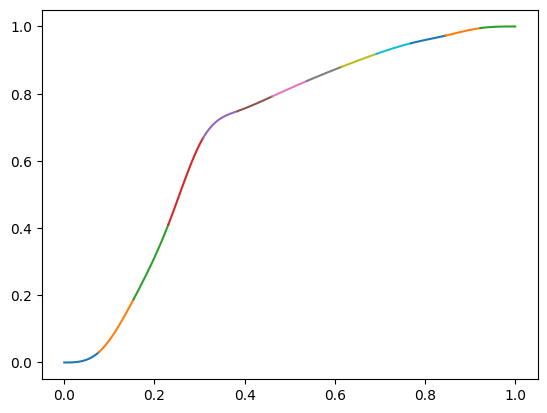

In [87]:
cdf.plot()

In [88]:
import math
math.pi, np.pi

(3.141592653589793, 3.141592653589793)

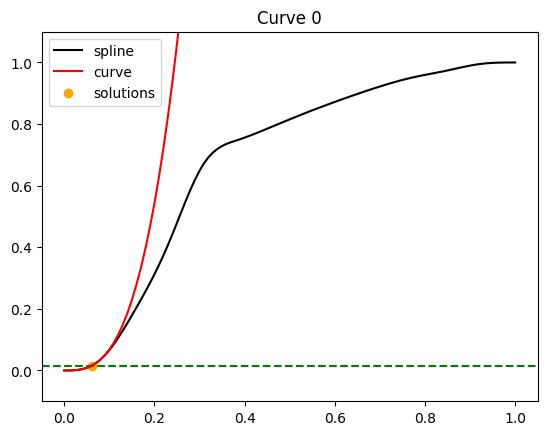

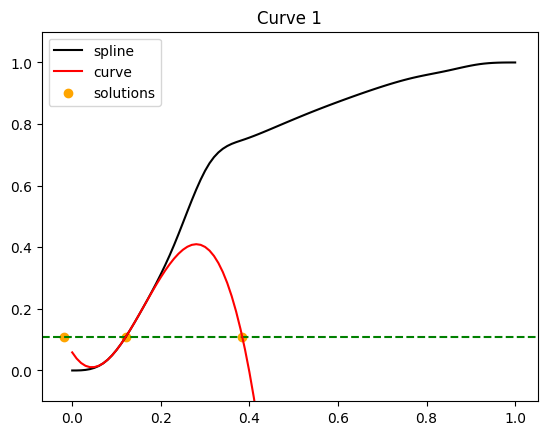

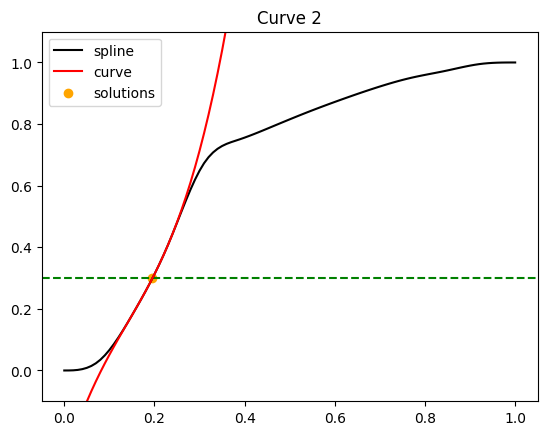

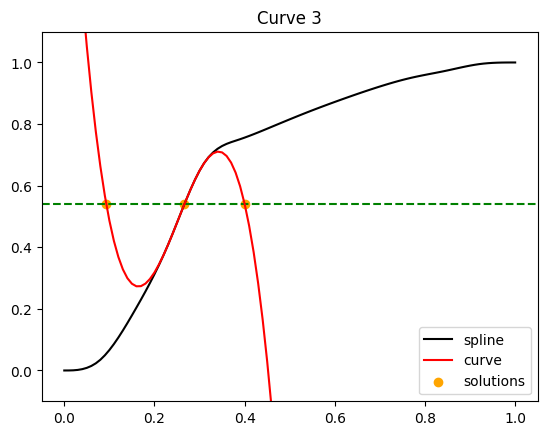

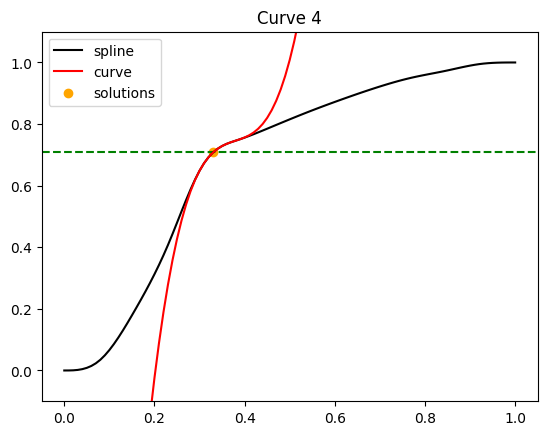

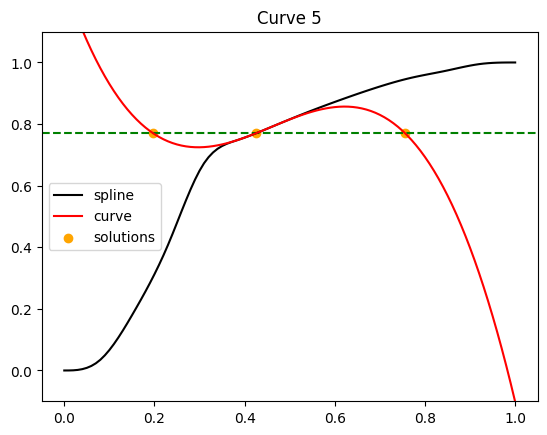

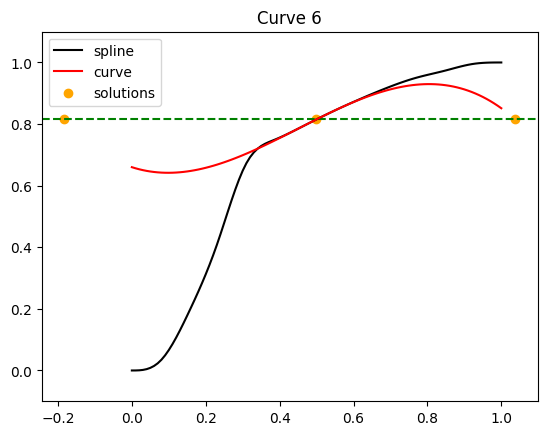

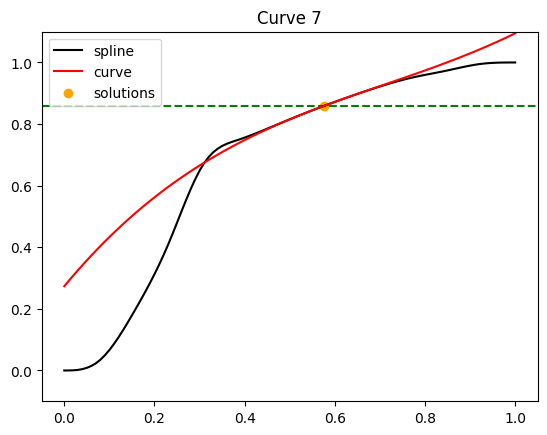

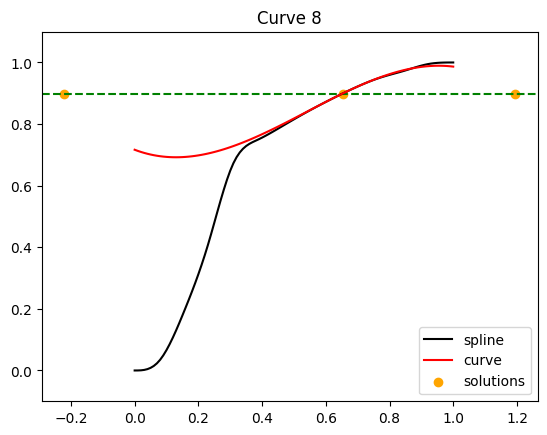

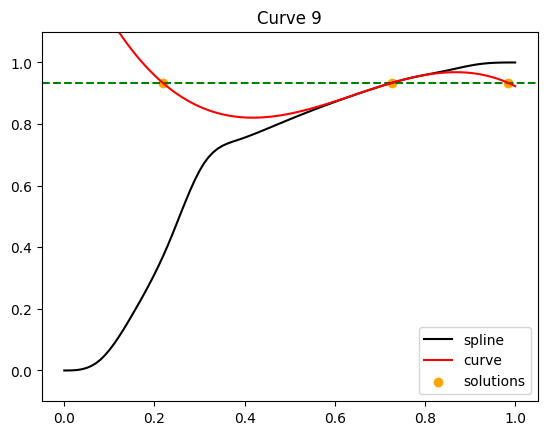

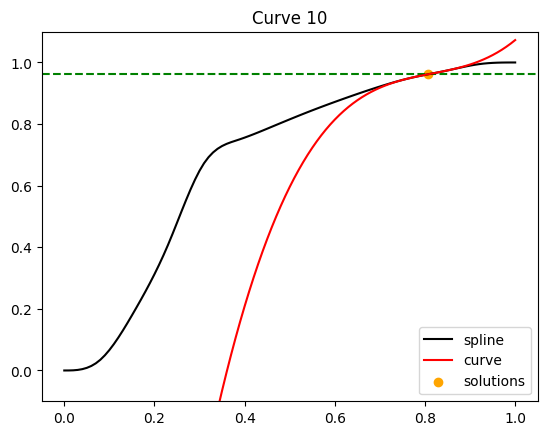

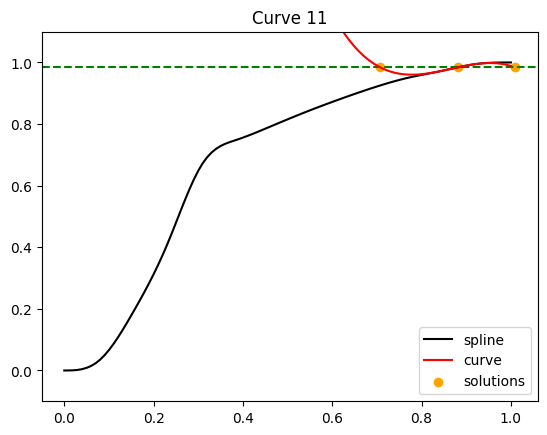

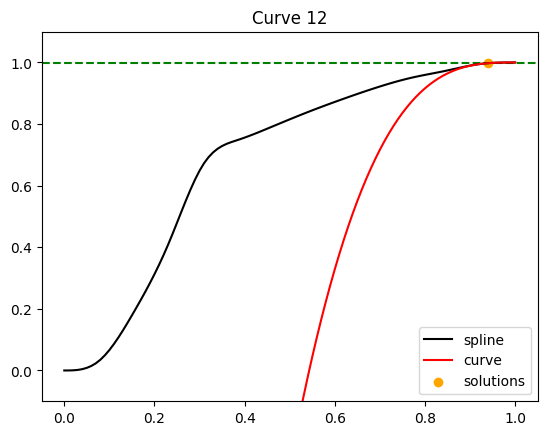

In [89]:
midpoints = (cdf.end_points[:-1] + cdf.end_points[1:]) / 2

failures = 0
for midpoint in midpoints:
    curve_ind = cdf.get_curve_index(midpoint)[0]
    curve = cdf.get_curve(curve_ind)
    solutions = curve.solve(midpoint)

    ts = np.linspace(0, 1, 101)
    spline_ys = cdf.get_y_batched(ts)
    curve_ys = curve(ts)

    plt.axhline(midpoint, color='green', linestyle='--')
    plt.plot(ts, spline_ys, color='black', label='spline')
    plt.plot(ts, curve_ys, color='red', label='curve')
    plt.scatter(solutions, np.array([midpoint] * solutions.shape[0]), color='orange', label='solutions')
    plt.title(f'Curve {curve_ind}')
    plt.legend()
    plt.ylim(-0.1, 1.1)
    plt.show()
    

### Lol, we can sample now XD bahahahahahahaha what a stupid amount of work to make this functional

In [90]:
# I can't believe this is actually not slow at all
cdf.sample(10)

array([0.48830091, 0.39288057, 0.23735986, 0.89424433, 0.18838358,
       0.21573493, 0.25590425, 0.34553389, 0.27843236, 0.25332909])

In [92]:
normal_bids.shape

(100000,)

In [102]:
batch_size = 1000
buffer_size = 4000
n_epochs = 5

# replay buffer-ish type thing? 4000
bids = []
floors = []
other_new_bids = [] # So we can compare actual revenue from this strategy against uniform sampling

# brand new density estimator
thompson_sampler = SimpleDensityEstimator(12)

for i in range(0, normal_bids.shape[0], batch_size):
    bids.extend(normal_bids[i:i+batch_size])
    floors.extend(thompson_sampler.get_cdf_spline().sample(1000))
    bids = bids[max(0, len(bids) - buffer_size):]
    floors = floors[max(0, len(floors) - buffer_size):]
    
    cond = np.array(floors) > np.array(bids) * 1.2
    over_pred_vec = cond.astype(int).astype(np.float64)
    other_new_bids.extend(np.where(
        cond[-batch_size:],
        0.0,
        np.maximum(
            np.array(bids[-batch_size:]),
            np.array(floors[-batch_size:])
        )
    ))
    
    thompson_sampler.train_cdf(np.array(floors), over_pred_vec, n_epochs=n_epochs, batch_size=batch_size, verbose=False)

bids = np.array(bids)
floors = np.array(floors)
other_new_bids = np.array(other_new_bids)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.29it/s]


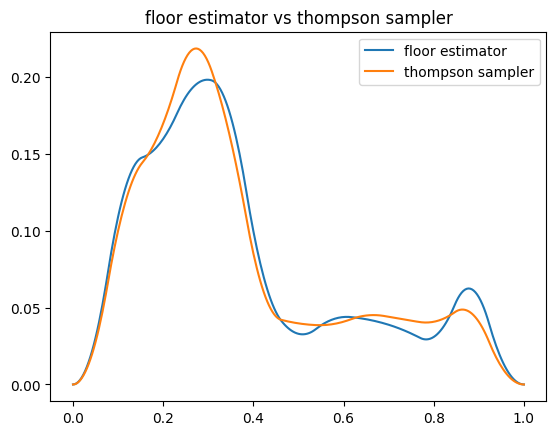

In [103]:
floor_estimator.get_spline().plot(segmented=False, label='floor estimator')
thompson_sampler.get_spline().plot(segmented=False, label='thompson sampler')
plt.title('floor estimator vs thompson sampler')
plt.legend()
plt.show()

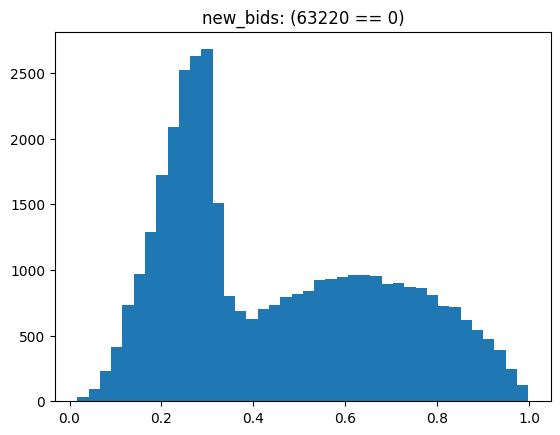

In [105]:
plt.hist(new_bids[np.where(new_bids != 0)], bins=40)
plt.title('new_bids: (' + str((new_bids == 0).sum()) + ' == 0)')
plt.show()

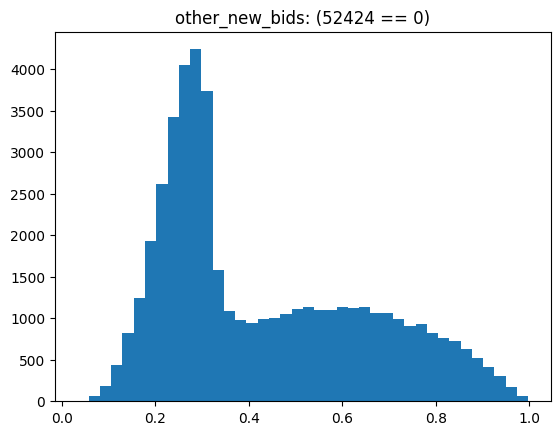

In [104]:
plt.hist(np.array(other_new_bids)[np.where(other_new_bids != 0)], bins=40)
plt.title('other_new_bids: (' + str((np.array(other_new_bids) == 0).sum()) + ' == 0)')
plt.show()

In [106]:
max_bids = normal_bids * 1.2

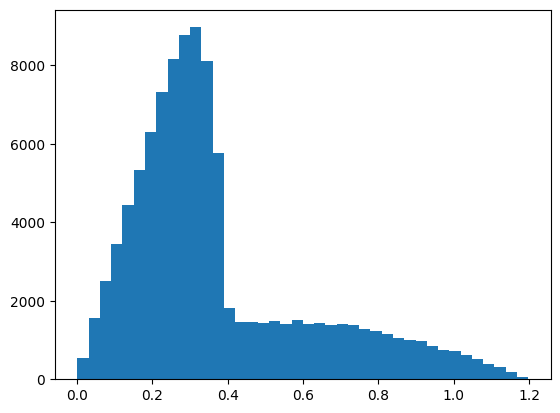

In [107]:
plt.hist(max_bids, bins=40)
plt.show()

In [108]:
np.mean(normal_bids), np.mean(new_bids), np.mean(other_new_bids), np.mean(max_bids)

(0.3120510131864623,
 0.1663634709818208,
 0.2050085702005089,
 0.37446121582375463)

That's fascinating. The Thompson sampler was better at staying under the threshold and it generated more revenue that the uniformly sampled floors. It also seems to have a smoother distribution. There's less of a peak at the end on the right side. Thinking about it now, it makes a ton of sense for the altered distribution to have a peak near the end because of all the max bids that are greater than the domain of the space (>1.0). Also fascinating that the thompson sampler differs from the uniformly sampled distribution.

Oh yeah, let's just double check that the sampling method is working.

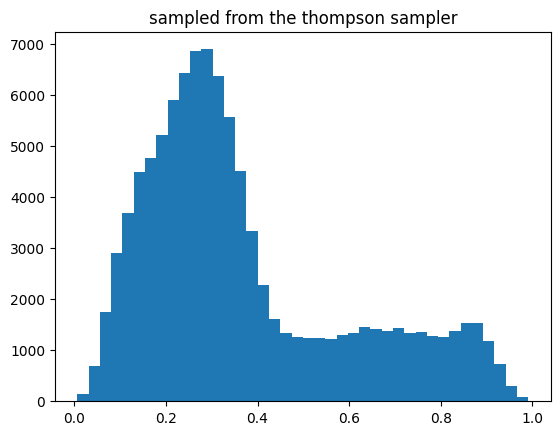

In [111]:
plt.hist(thompson_sampler.get_cdf_spline().sample(100_000), bins=40)
plt.title('sampled from the thompson sampler')
plt.show()

In [ ]:
# I'd say that fits the thompson

In [113]:
%%time
thompson_sampler.get_cdf_spline().sample(100_000)

CPU times: total: 6.05 s
Wall time: 6.92 s


array([0.78649584, 0.11987402, 0.30633155, ..., 0.29727292, 0.18294586,
       0.08868788])

In [115]:
%%time
thompson_sampler.get_cdf_spline().sample(1)

CPU times: total: 0 ns
Wall time: 1e+03 µs


0.19133831942500323

## FlexibleDensityEstimator

In [134]:
from spline_distribution.tensorflow.distribution import FlexibleDensityEstimator

## Train PDF

In [144]:
estimator = FlexibleDensityEstimator(3)

In [145]:
spline = estimator.get_spline()

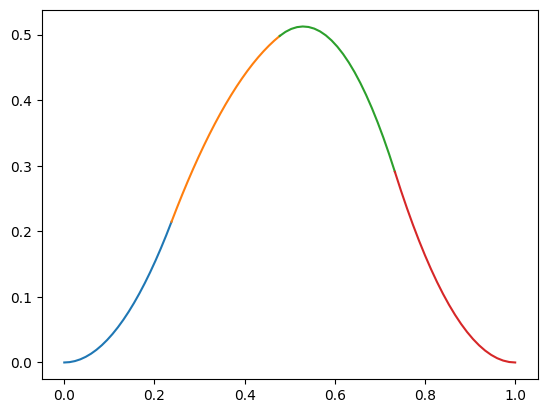

In [146]:
spline.plot()

In [147]:
estimator.area()

0.24840825183109158

In [148]:
estimator.expected_value()

0.5074960106519651

In [149]:
import tensorflow as tf
import numpy as np

In [151]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000), dtype=tf.float64)

In [152]:
estimator.train(ts, n_epochs=20, batch_size=4096)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19


In [153]:
spline = estimator.get_spline()

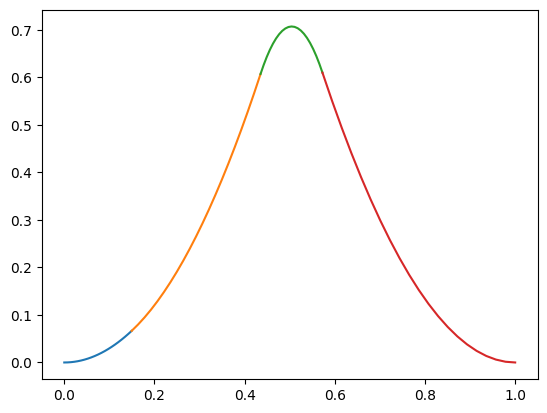

In [154]:
spline.plot()

In [155]:
estimator.expected_value()

0.4818150046804372

## Train CDF

In [156]:
estimator = FlexibleDensityEstimator(7)

In [157]:
spline = estimator.get_spline()

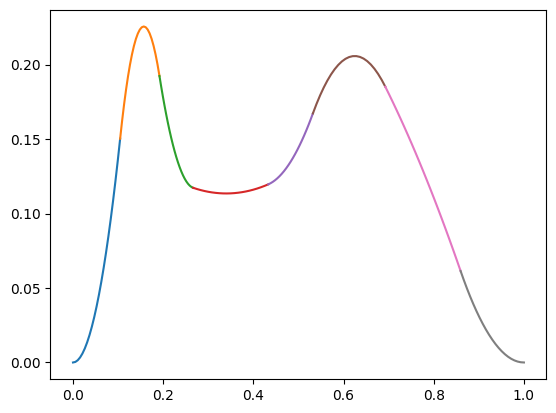

In [158]:
spline.plot()

In [159]:
estimator.expected_value()

0.45961369641819544

In [163]:
ts = tf.convert_to_tensor(np.random.normal(0.5, 0.05, size=100_000), dtype=tf.float64)
t_preds = tf.convert_to_tensor(np.random.uniform(size=100_000), dtype=tf.float64)
over_pred_vec = tf.where(t_preds > ts, 1.0, 0.0)

In [166]:
estimator.train_cdf(t_preds, over_pred_vec, n_epochs=20, batch_size=1024)

Epoch 1/20 42.191976844710005
Epoch 2/20 38.757277480048884
Epoch 3/20 35.88285460616537
Epoch 4/20 33.46405935713097
Epoch 5/20 31.36692080901364
Epoch 6/20 29.497445068250194
Epoch 7/20 27.796407625498006
Epoch 8/20 26.22935381715644
Epoch 9/20 24.77619785966306
Epoch 10/20 23.42430384279583
Epoch 11/20 22.164847002695865
Epoch 12/20 20.99111409319195
Epoch 13/20 19.897721601343953
Epoch 14/20 18.880207330634796
Epoch 15/20 17.934805026076354
Epoch 16/20 17.058304000413635
Epoch 17/20 16.24793755533045
Epoch 18/20 15.501252093188107
Epoch 19/20 14.815992408085028
Epoch 20/20 14.190009883789482


In [167]:
spline = estimator.get_spline()

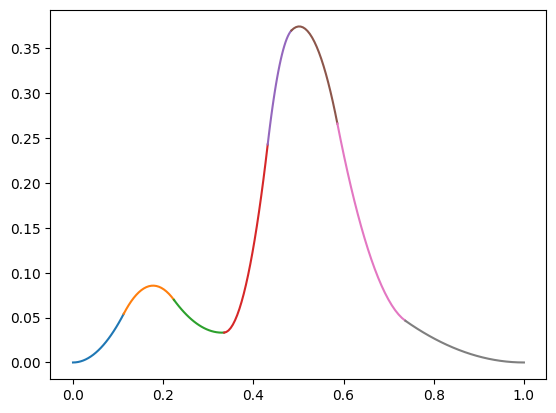

In [168]:
spline.plot()

In [169]:
estimator.expected_value()

0.48112531403836234

### Try the auction simulation again

In [170]:
n_bidders = 5
n_items = 100_000
values = np.random.uniform(size=n_items)
get_smart_p = np.random.uniform(size=(n_items, n_bidders))
perceptions = np.sqrt(np.random.uniform(size=(n_items, n_bidders)) * values.reshape((-1, 1)))
perceptions = np.where(get_smart_p > 0.9, perceptions, perceptions / 3)

In [171]:
normal_bids = perceptions.max(axis=1)

In [172]:
normal_bids.shape

(100000,)

In [173]:
(get_smart_p.max(axis=1) > 0.9).sum()

40757

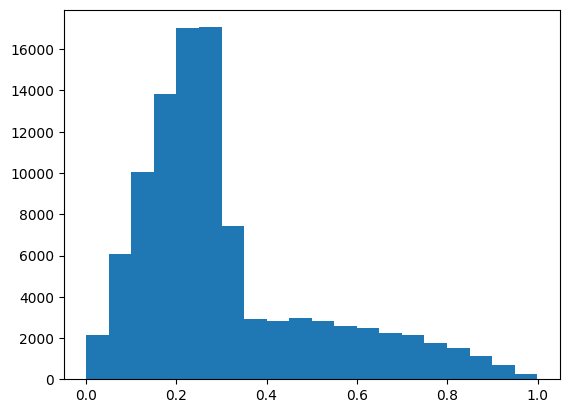

In [174]:
import matplotlib.pyplot as plt
plt.hist(normal_bids, bins=20)
plt.show()

In [175]:
bid_estimator = FlexibleDensityEstimator(7)

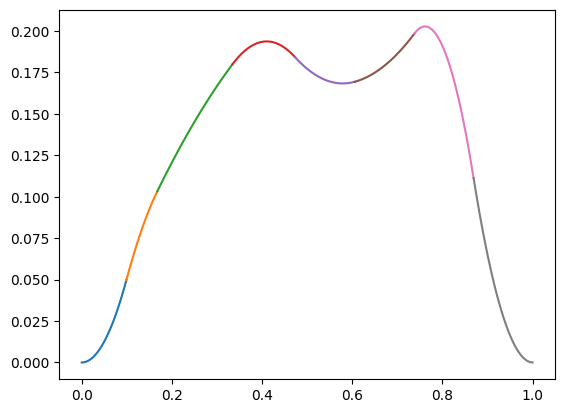

In [176]:
bid_estimator.get_spline().plot()

In [179]:
bid_estimator.train(tf.convert_to_tensor(normal_bids, dtype=tf.float64), n_epochs=20, batch_size=1024)

Epoch 1/20 7.514506853878905
Epoch 2/20 -4.533318516832701
Epoch 3/20 -13.820274929204912
Epoch 4/20 -20.890422779276328
Epoch 5/20 -25.914204374254368
Epoch 6/20 -29.304399974826083
Epoch 7/20 -31.504389060650364
Epoch 8/20 -32.7929559449206
Epoch 9/20 -33.30481104138031
Epoch 10/20 -33.12466090594774
Epoch 11/20 -32.35035950428754
Epoch 12/20 -31.08821269884579
Epoch 13/20 -29.415882565298823
Epoch 14/20 -27.357609085669253
Epoch 15/20 -24.864029535349875
Epoch 16/20 -21.838024378231143
Epoch 17/20 -18.248356547350692
Epoch 18/20 -14.214107060343897
Epoch 19/20 -9.929160413176717
Epoch 20/20 -5.572496296176819


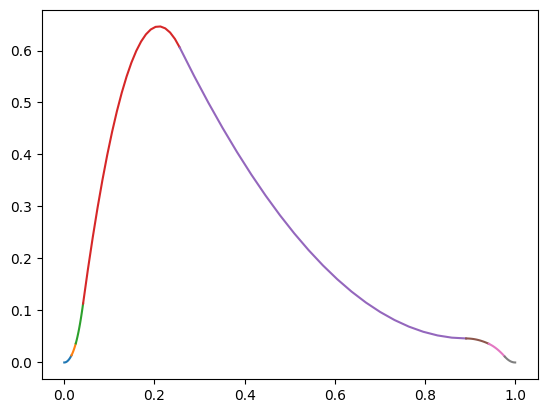

In [180]:
bid_estimator.get_spline().plot()

In [181]:
bid_estimator.expected_value()

0.4491949292399422

In [182]:
normal_bids.mean()

0.30960216945858293

#### Look at it, it's beautiful

Now I want to train a distribution that looks at what happens if we interfere

In [183]:
floor_estimator = FlexibleDensityEstimator(12)

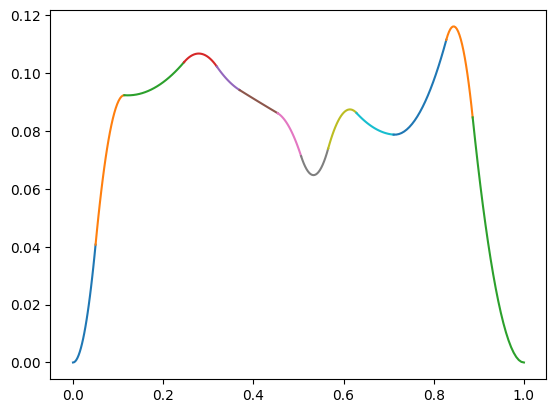

In [184]:
floor_estimator.get_spline().plot()

In [185]:
floors = np.random.uniform(0.01, 0.99, size=100_000)
new_bids = np.where(floors > normal_bids, 0.0, np.maximum(floors, normal_bids))
over_pred_vec = (new_bids == 0).astype(int)

In [186]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024)

Epoch 1/20 41.73400504654024
Epoch 2/20 38.05432687381379
Epoch 3/20 35.91095934864737
Epoch 4/20 34.76481284812099
Epoch 5/20 34.20098085076265
Epoch 6/20 33.94081181206794
Epoch 7/20 33.82354360287388
Epoch 8/20 33.76955580069223
Epoch 9/20 33.74345962686136
Epoch 10/20 33.73004637156973
Epoch 11/20 33.72256542494695
Epoch 12/20 33.71791037668194
Epoch 13/20 33.714654109894035
Epoch 14/20 33.71215679364293
Epoch 15/20 33.71013310053796
Epoch 16/20 33.70844772654145
Epoch 17/20 33.70702577088755
Epoch 18/20 33.70581681153259
Epoch 19/20 33.70478170724618
Epoch 20/20 33.70388807429902


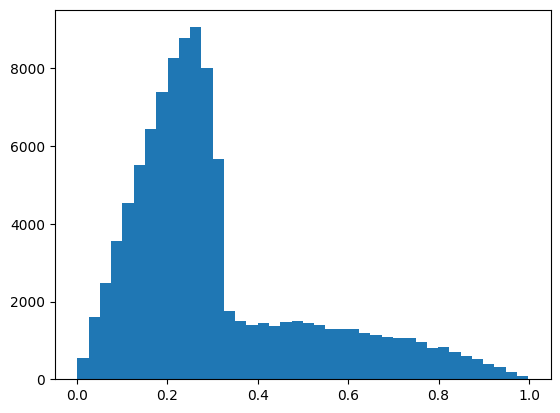

In [187]:
plt.hist(normal_bids, bins=40)
plt.show()

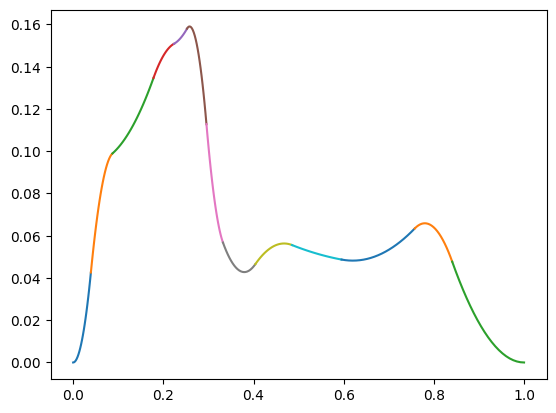

In [188]:
floor_estimator.get_spline().plot()

### I have no idea why training on the CDF is working so much better than training on the PDF

In [189]:
floor_estimator = FlexibleDensityEstimator(12)

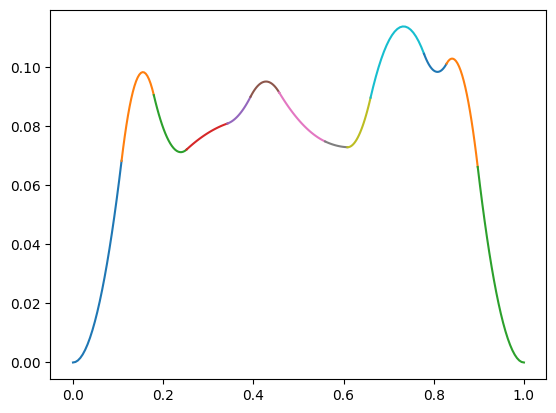

In [190]:
floor_estimator.get_spline().plot()

In [191]:
floors = np.random.uniform(0.01, 0.99, size=100_000)
new_bids = np.where(floors > normal_bids * 1.5, 0.0, np.maximum(floors, normal_bids))
over_pred_vec = (new_bids == 0).astype(int)

In [192]:
floor_estimator.train_cdf(
    tf.convert_to_tensor(floors, dtype=tf.float64),
    tf.convert_to_tensor(over_pred_vec, dtype=tf.float64),
    n_epochs=20,
    batch_size=1024)

Epoch 1/20 49.28857827235982
Epoch 2/20 48.015496919152625
Epoch 3/20 47.296258137106896
Epoch 4/20 46.78181119014084
Epoch 5/20 46.37202766940481
Epoch 6/20 46.03688335539891
Epoch 7/20 45.76112277660449
Epoch 8/20 45.5330191862379
Epoch 9/20 45.34298393488631
Epoch 10/20 45.18349807429481
Epoch 11/20 45.04881106950852
Epoch 12/20 44.9344353074793
Epoch 13/20 44.836872801592996
Epoch 14/20 44.75327318700557
Epoch 15/20 44.68125250182834
Epoch 16/20 44.61892712741697
Epoch 17/20 44.56481006046258
Epoch 18/20 44.517704267771684
Epoch 19/20 44.47658092265314
Epoch 20/20 44.440555511204536


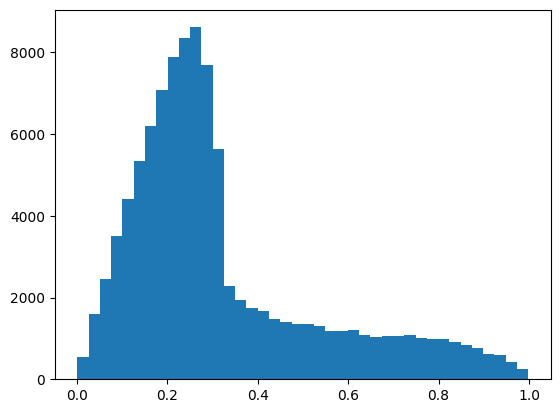

In [193]:
plt.hist(np.where(new_bids == 0, normal_bids, new_bids), bins=40)
plt.show()

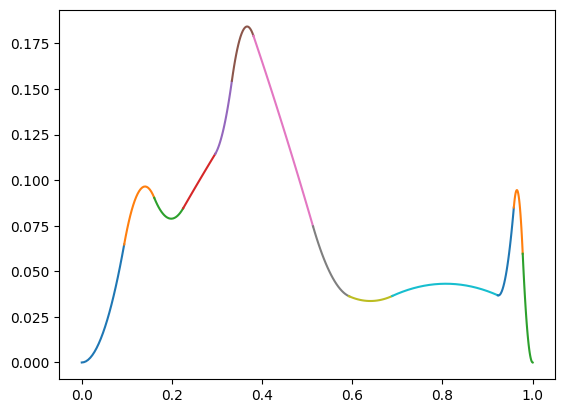

In [194]:
floor_estimator.get_spline().plot()

### There are some artifacts in the flexible estimator that I'm not quite able to understand